In [1]:
import sys
sys.path.append(r"C:\traffic-demand-final\pipelining\src")
import os
import pandas as pd
import numpy as np
from config import *

# Load train and test data
train = pd.read_csv(os.path.join(PROC_DIR, 'train_step01.csv'))
test = pd.read_csv(os.path.join(PROC_DIR, 'test_step01.csv'))

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (77299, 11)
Test shape: (41778, 10)


In [2]:
# Print null count for Temperature before imputation
train_nulls = train['Temperature'].isnull().sum()
test_nulls = test['Temperature'].isnull().sum()

train_pct = train_nulls / len(train) * 100
test_pct = test_nulls / len(test) * 100

print(f"Train Temperature nulls: {train_nulls} ({train_pct:.2f}%)")
print(f"Test Temperature nulls: {test_nulls} ({test_pct:.2f}%)")

Train Temperature nulls: 2495 (3.23%)
Test Temperature nulls: 1349 (3.23%)


In [3]:
# Compute geohash group median on train
geohash_temp_median = train.groupby('geohash')['Temperature'].median().to_dict()
global_train_median = train['Temperature'].median()

# Keep a mask of nulls to count how they are filled
train_null_mask = train['Temperature'].isnull()

# Find which rows will use geohash vs global fallback
geohash_mapped_train = train.loc[train_null_mask, 'geohash'].map(geohash_temp_median)
geohash_fill_count = geohash_mapped_train.notnull().sum()
global_fill_count = geohash_mapped_train.isnull().sum()

# Fill using geohash median, fallback to global median
train['Temperature'] = train['Temperature'].fillna(train['geohash'].map(geohash_temp_median))
train['Temperature'] = train['Temperature'].fillna(global_train_median)

print(f"Train rows filled by geohash median: {geohash_fill_count}")
print(f"Train rows filled by global median fallback: {global_fill_count}")
print(f"Train Temperature nulls after imputation: {train['Temperature'].isnull().sum()}")

Train rows filled by geohash median: 2495
Train rows filled by global median fallback: 0
Train Temperature nulls after imputation: 0


Geohash group median imputation is preferred over a simple global median because temperature is highly localized based on geography. Areas in the same geohash experience similar weather conditions. We compute this strictly from the training data to prevent data leakage into the test set.

In [4]:
# Apply same imputation to test
test_null_mask = test['Temperature'].isnull()

# Find which rows will use geohash vs global fallback
test_geohash_mapped = test.loc[test_null_mask, 'geohash'].map(geohash_temp_median)
test_geohash_fill_count = test_geohash_mapped.notnull().sum()
test_global_fill_count = test_geohash_mapped.isnull().sum()

# Use train-derived dictionary and fallback
test['Temperature'] = test['Temperature'].fillna(test['geohash'].map(geohash_temp_median))
test['Temperature'] = test['Temperature'].fillna(global_train_median)

print(f"Test rows filled by geohash median: {test_geohash_fill_count}")
print(f"Test rows filled by global median fallback: {test_global_fill_count}")
print(f"Test Temperature nulls after imputation: {test['Temperature'].isnull().sum()}")

Test rows filled by geohash median: 1349
Test rows filled by global median fallback: 0
Test Temperature nulls after imputation: 0


The exact same median values derived from the training set are used to fill missing values in the test set. If any geohash is present in the test set but absent in the training set, we fall back to the global training median. This rigorous separation prevents leakage.

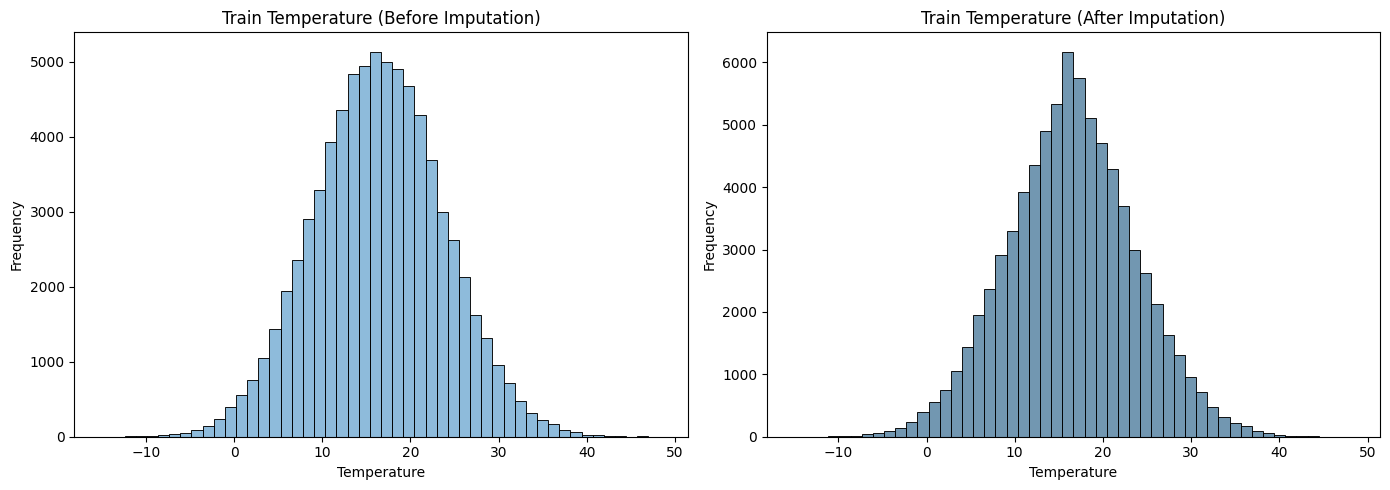

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the before imputation values again to compare
train_before = pd.read_csv(os.path.join(PROC_DIR, 'train_step01.csv'))['Temperature']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use the project palette Blues_d
palette = sns.color_palette("Blues_d", 2)

sns.histplot(train_before.dropna(), bins=50, color=palette[0], alpha=0.7, ax=axes[0])
axes[0].set_title('Train Temperature (Before Imputation)')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('Frequency')

sns.histplot(train['Temperature'], bins=50, color=palette[1], alpha=0.7, ax=axes[1])
axes[1].set_title('Train Temperature (After Imputation)')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(UNIVARIATE_PLOTS_DIR, 'temperature_imputation_comparison.png'))
plt.show()

The overall shape and distribution of Temperature remain highly consistent before and after imputation. This indicates that the localized geohash median strategy successfully filled missing values without distorting the underlying data properties.

In [6]:
# Final null check
train_null_summary = train.isnull().sum()
test_null_summary = test.isnull().sum()

if train_null_summary.sum() == 0 and test_null_summary.sum() == 0:
    print("Zero nulls remain in train and test datasets.")
else:
    print("WARNING: Nulls found!")
    if train_null_summary.sum() > 0:
        print("\nTrain Nulls:")
        print(train_null_summary[train_null_summary > 0])
    if test_null_summary.sum() > 0:
        print("\nTest Nulls:")
        print(test_null_summary[test_null_summary > 0])

Zero nulls remain in train and test datasets.


In [7]:
# Save train and test to PROC_DIR
train_save_path = os.path.join(PROC_DIR, 'train_step02.csv')
test_save_path = os.path.join(PROC_DIR, 'test_step02.csv')

train.to_csv(train_save_path, index=False)
test.to_csv(test_save_path, index=False)

print(f"Saved train to: {train_save_path} (Shape: {train.shape})")
print(f"Saved test to: {test_save_path} (Shape: {test.shape})")

Saved train to: C:\traffic-demand-final\pipelining\processed\train_step02.csv (Shape: (77299, 11))
Saved test to: C:\traffic-demand-final\pipelining\processed\test_step02.csv (Shape: (41778, 10))


# Step 02 Complete — What Was Done

* Counted how many Temperature nulls existed before imputation in both train and test
* Used geohash group median imputation, which is better than global median because temperature is localized
* Computed medians strictly on train and applied to test to avoid leakage
* Tracked how many rows used the geohash median versus the global median fallback
* Verified that the temperature distribution was preserved after imputation
* Saved the fully imputed datasets to PROC_DIR as train_step02.csv and test_step02.csv
* The next step is Step 03: Encoding